<a href="https://colab.research.google.com/github/tinemyumi/saude-mental-datasus/blob/main/notebooks/9.analise_drs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Fluxo Entre DRS (Departamentos Regionais de Saúde)**

**Objetivo**

Analisar o fluxo de internações hospitalares no estado de São Paulo, com foco nos Departamentos Regionais de Saúde (DRS), identificando:
- Se os pacientes conseguem se internar dentro da própria DRS de residência ou precisam se deslocar para outra região
- DRS polo de internação (que concentram pacientes provenientes de outras regiões)
- DRS exportadoras de pacientes (evasão para outras DRS)
- Variação desses padrões entre os períodos pré-pandemia, pandemia e pós-pandemia

**Autor:** Larissa Tinem

# **1. Setup**

In [ ]:
!pip install geobr -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 338.0/338.0 kB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 32.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 36.7 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import seaborn as sns
import geopandas as gpd
import geobr
from scipy import stats
from matplotlib.lines import Line2D
from matplotlib.patches import FancyArrowPatch
from matplotlib.colors import LinearSegmentedColormap
import warnings
warnings.filterwarnings('ignore')

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Paleta e estilo
COLOR1 = '#1B4F72'
COLOR2 = '#48C9B0'
COLOR3 = '#5499C7'
COLOR_WARN = '#E74C3C'
COLOR_MID  = '#F39C12'

PALETTE_PERIODO = {
    'Pré-pandemia' : COLOR1,
    'Pandemia'     : COLOR2,
    'Pós-pandemia' : COLOR3,
}
ORDEM_PERIODOS = ['Pré-pandemia', 'Pandemia', 'Pós-pandemia']

plt.rcParams['figure.dpi']        = 120
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
sns.set_style('whitegrid')

In [ ]:
import geopandas as gpd

# Carrega geometria dos municípios de SP via geobr
print('Carregando geometria...')
municipios_sp = geobr.read_municipality(code_muni='SP', year=2020)
municipios_sp['cod6'] = municipios_sp['code_muni'].astype(str).str[:6]
print(f'Municípios SP no mapa: {len(municipios_sp)}')

Carregando geometria...
Municípios SP no mapa: 645


# **2. Carregamento dos dados**

In [ ]:
df = pd.read_parquet('/content/drive/MyDrive/Dados/dados_tratados/df_sihsus.parquet')
df_drs = pd.read_csv('/content/drive/MyDrive/Dados/dados_tratados/df_drs.csv')
df_pop = pd.read_csv('/content/drive/MyDrive/Dados/dados_tratados/df_populacao_sp')

In [ ]:
print('Colunas do DF: ')
print(df.columns.tolist())
print('-'*50)
print('Colunas do DF DRS: ')
print(df_drs.columns.tolist())
print('-'*50)
print('Colunas do DF População: ')
print(df_pop.columns.tolist())

Colunas do DF: 
['N_AIH', 'cod_municipio', 'IDENT', 'ANO_CMPT', 'MES_CMPT', 'NASC', 'IDADE', 'SEXO', 'RACA_COR', 'ESPEC', 'MUNIC_RES', 'CEP', 'DIAG_PRINC', 'DIAG_SECUN', 'CAR_INT', 'COBRANCA', 'MUNIC_MOV', 'CID_ASSO', 'CID_MORTE', 'COMPLEX', 'DT_INTER', 'DT_SAIDA', 'QT_DIARIAS', 'DIAS_PERM', 'MORTE', 'periodo_pandemia']
--------------------------------------------------
Colunas do DF DRS: 
['cod_municipio', 'municipio', 'cod_drs', 'drs']
--------------------------------------------------
Colunas do DF População: 
['ano', 'cod_municipio', 'nome_municipio', 'sigla_uf', 'populacao']


# **3. Análise - Desigualdade Geográfica das Internações**

In [ ]:
# PADRONIZAÇÃO

df['MUNIC_RES'] = df['MUNIC_RES'].astype(str).str.zfill(6)
df['MUNIC_MOV'] = df['MUNIC_MOV'].astype(str).str.zfill(6)

df_pop['cod_municipio'] = df_pop['cod_municipio'].astype(str).str.zfill(6)
df_drs['cod_municipio'] = df_drs['cod_municipio'].astype(str).str.zfill(6)

In [ ]:
# -----------------------------------------------------
# ANEXAR DRS DE RESIDÊNCIA E DRS DE INTERNAÇÃO
# -----------------------------------------------------

# DRS residência

df = df.merge(
    df_drs[['cod_municipio', 'drs']],
    left_on='MUNIC_RES',
    right_on='cod_municipio',
    how='left',
    suffixes=('', '_aux')
)

df.rename(columns={'drs': 'drs_res'}, inplace=True)
df.drop(columns=['cod_municipio'], inplace=True, errors='ignore')

# DRS internação

df = df.merge(
    df_drs[['cod_municipio', 'drs']],
    left_on='MUNIC_MOV',
    right_on='cod_municipio',
    how='left',
    suffixes=('', '_aux')
)

df.rename(columns={'drs': 'drs_mov'}, inplace=True)
df.drop(columns=['cod_municipio'], inplace=True, errors='ignore')

In [ ]:
# -----------------------------------------------------
# CRIAR FLUXO INTERMUNICIPAL E INTER-DRS
# -----------------------------------------------------
df['fluxo_municipio'] = np.where(
    df['MUNIC_RES'] == df['MUNIC_MOV'],
    'mesmo_municipio',
    'fora_municipio'
)

df['fluxo_drs'] = np.where(
    df['drs_res'] == df['drs_mov'],
    'mesma_drs',
    'fora_drs'
)

In [ ]:
# -----------------------------------------------------
# POPULAÇÃO MÉDIA POR DRS
# -----------------------------------------------------

pop_drs = (
    df_pop
    .merge(
        df_drs[['cod_municipio', 'drs']],
        on='cod_municipio',
        how='left'
    )
    .groupby('drs')['populacao']
    .mean()
    .reset_index(name='populacao_drs')
)

In [ ]:
# -----------------------------------------------------
# % de internações na mesma DRS vs fora da DRS
# total do período analisado
# -----------------------------------------------------

import pandas as pd

# total internações
total = len(df)

# mesma DRS
mesma = (df['fluxo_drs'] == 'mesma_drs').sum()

# fora da DRS
fora = (df['fluxo_drs'] == 'fora_drs').sum()

# percentuais
perc_mesma = (mesma / total) * 100
perc_fora  = (fora / total) * 100

# tabela resumo
resumo_fluxo = pd.DataFrame({
    'categoria': ['Mesma DRS', 'Fora da DRS'],
    'internacoes': [mesma, fora],
    'percentual_%': [perc_mesma, perc_fora]
})

resumo_fluxo['percentual_%'] = resumo_fluxo['percentual_%'].round(2)

print(resumo_fluxo)

     categoria  internacoes  percentual_%
0    Mesma DRS      1001323         92.74
1  Fora da DRS        78347          7.26


TOP 10 DRS EXPORTADORAS (POR TAXA)


,ranking,drs,pacientes_exportados,taxa_100k
16,1,DRS Taubaté,13803,24055.18
8,2,DRS Marília,2943,16905.28
4,3,DRS Bauru,2551,10728.43
11,4,DRS Registro,1866,10179.72
7,5,DRS Grande São Paulo,33610,6756.23
14,6,DRS São José do Rio Preto,984,6718.11
5,7,DRS Campinas,5820,6154.41
10,8,DRS Presidente Prudente,897,5534.82
1,9,DRS Araçatuba,818,4509.31
13,10,DRS Sorocaba,1884,3983.36


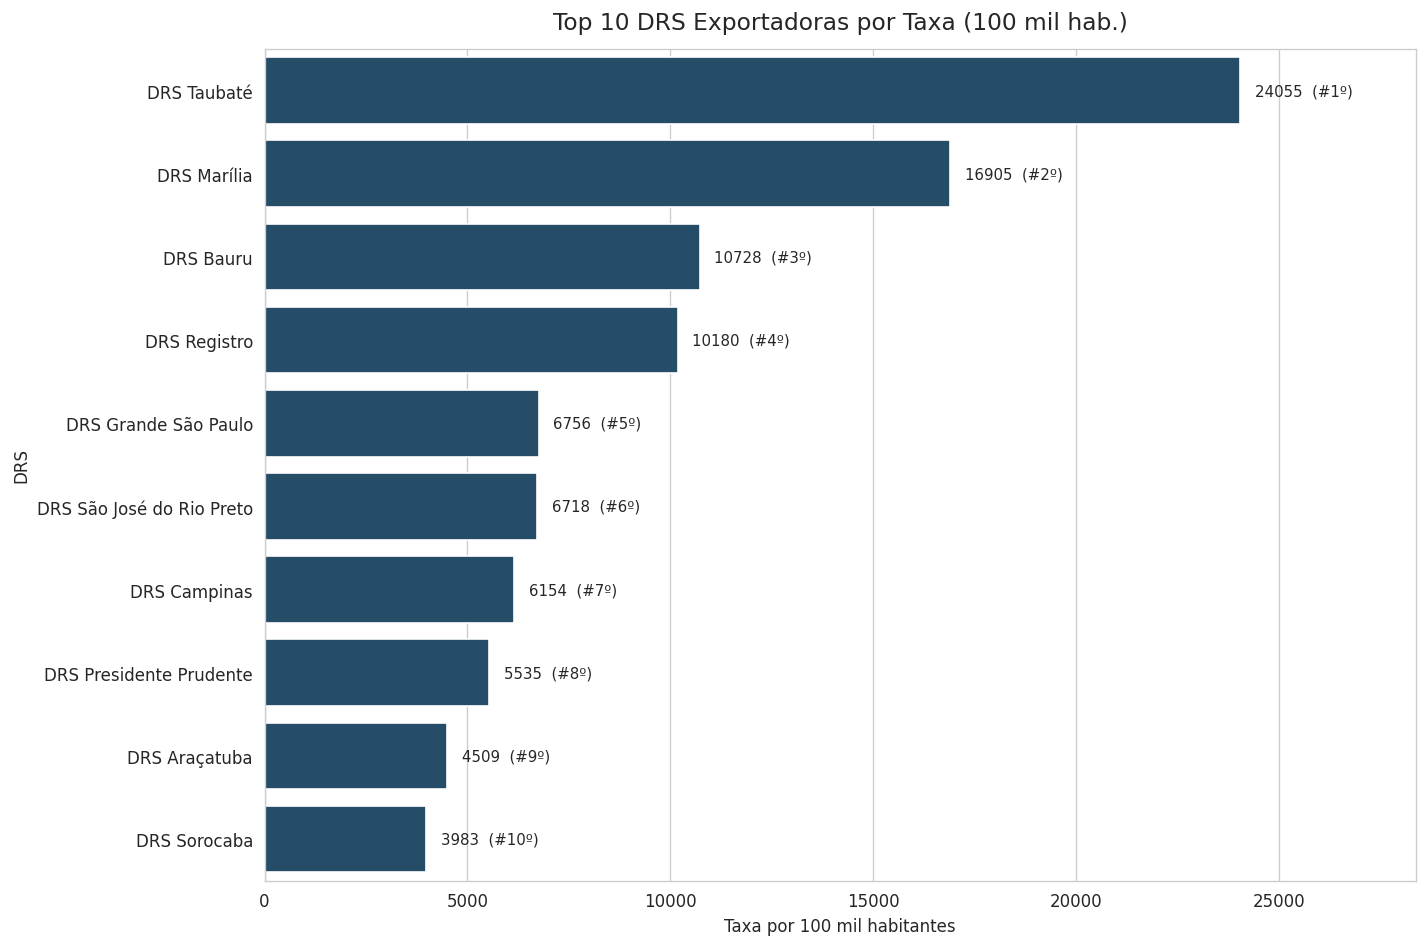

In [ ]:
# =====================================================
# TOP 10 DRS EXPORTADORAS
# Taxa por 100 mil + ranking estadual
# =====================================================

# -----------------------------------------------------
# EXPORTAÇÃO DE PACIENTES
# -----------------------------------------------------

exportadores_drs = (
    df[df['fluxo_drs'] == 'fora_drs']
    .groupby('drs_res')
    .size()
    .reset_index(name='pacientes_exportados')
)

exportadores_drs.rename(columns={'drs_res': 'drs'}, inplace=True)

# -----------------------------------------------------
# JUNTAR POPULAÇÃO
# -----------------------------------------------------

exportadores_drs = exportadores_drs.merge(
    pop_drs,
    on='drs',
    how='left'
)

# -----------------------------------------------------
# TAXA POR 100 MIL HABITANTES
# -----------------------------------------------------

exportadores_drs['taxa_100k'] = (
    exportadores_drs['pacientes_exportados'] /
    exportadores_drs['populacao_drs']
) * 100000

exportadores_drs['taxa_100k'] = exportadores_drs['taxa_100k'].round(2)

# -----------------------------------------------------
# RANKING ESTADUAL (baseado na taxa, já normalizada)
# -----------------------------------------------------

exportadores_drs['ranking'] = (
    exportadores_drs['taxa_100k']
    .rank(ascending=False, method='min')
    .astype(int)
)

# -----------------------------------------------------
# RESULTADO TABELA
# -----------------------------------------------------

print("TOP 10 DRS EXPORTADORAS (POR TAXA)")

display(
    exportadores_drs
    .sort_values('taxa_100k', ascending=False)
    [['ranking', 'drs', 'pacientes_exportados', 'taxa_100k']]
    .head(10)
)

# -----------------------------------------------------
# GRÁFICO
# -----------------------------------------------------

top10 = (
    exportadores_drs
    .sort_values('taxa_100k', ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 8))

sns.barplot(
    data=top10,
    x='taxa_100k',
    y='drs',
    order=top10['drs'],
    color=COLOR1
)

plt.title('Top 10 DRS Exportadoras por Taxa (100 mil hab.)', fontsize=14, pad=12)
plt.xlabel('Taxa por 100 mil habitantes')
plt.ylabel('DRS')

offset = top10['taxa_100k'].max() * 0.015

for i, (_, row) in enumerate(top10.iterrows()):
    plt.text(
        row['taxa_100k'] + offset,
        i,
        f"{row['taxa_100k']:.0f}  (#{row['ranking']}º)",
        va='center',
        fontsize=9
    )

plt.xlim(right=top10['taxa_100k'].max() * 1.18)
plt.tight_layout()
plt.show()

TOP 10 DRS IMPORTADORAS (POR ÍNDICE DE ATRAÇÃO)


,ranking,drs,pacientes_importados,pacientes_exportados,saldo_liquido,indice_atracao
15,1,DRS São João da Boa Vista,45259,440,44819,0.990
13,2,DRS Sorocaba,10761,1884,8877,0.851
12,3,DRS Ribeirão Preto,4573,960,3613,0.826
4,4,DRS Bauru,6748,2551,4197,0.726
8,5,DRS Marília,2012,2943,-931,0.406
9,6,DRS Piracicaba,809,1964,-1155,0.292
10,7,DRS Presidente Prudente,289,897,-608,0.244
6,8,DRS Franca,232,848,-616,0.215
14,9,DRS São José do Rio Preto,209,984,-775,0.175
7,10,DRS Grande São Paulo,5760,33610,-27850,0.146


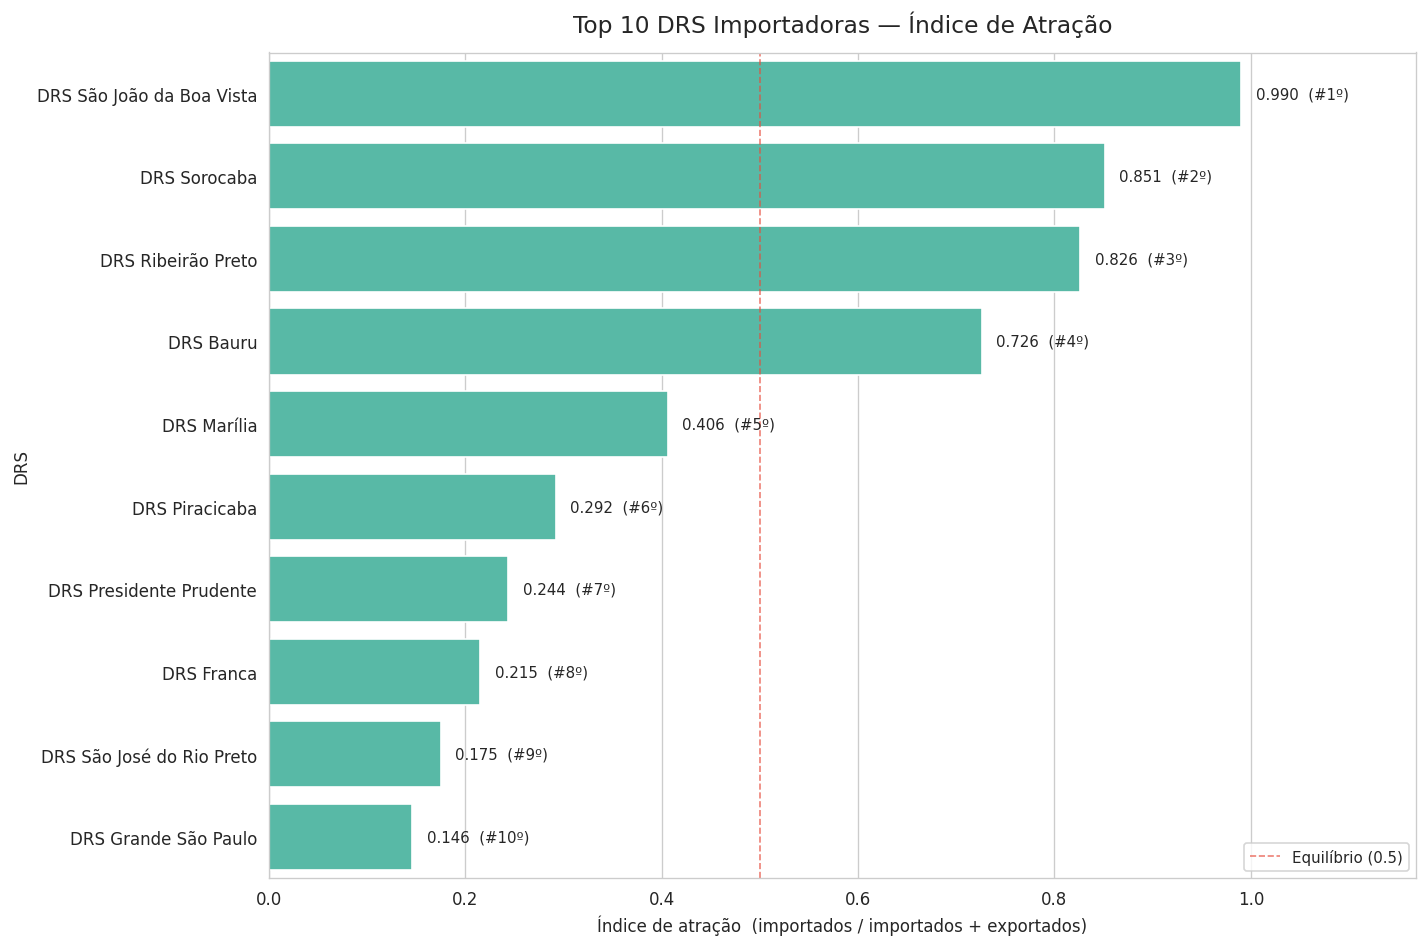

In [ ]:
# =====================================================
# TOP 10 DRS IMPORTADORAS
# Índice de atração + ranking estadual
# =====================================================

# -----------------------------------------------------
# IMPORTAÇÃO DE PACIENTES
# -----------------------------------------------------

importadores_drs = (
    df[df['fluxo_drs'] == 'fora_drs']
    .groupby('drs_mov')
    .size()
    .reset_index(name='pacientes_importados')
)

importadores_drs.rename(columns={'drs_mov': 'drs'}, inplace=True)

# -----------------------------------------------------
# JUNTAR EXPORTADOS (calculado anteriormente)
# para compor o índice de atração
# -----------------------------------------------------

importadores_drs = importadores_drs.merge(
    exportadores_drs[['drs', 'pacientes_exportados']],
    on='drs',
    how='left'
).fillna({'pacientes_exportados': 0})

# -----------------------------------------------------
# ÍNDICE DE ATRAÇÃO
# importados / (importados + exportados)
# 0 = nenhum paciente vindo de fora
# 1 = só recebe, não exporta ninguém
# -----------------------------------------------------

importadores_drs['indice_atracao'] = (
    importadores_drs['pacientes_importados'] /
    (importadores_drs['pacientes_importados'] + importadores_drs['pacientes_exportados'])
).round(3)

# -----------------------------------------------------
# SALDO LÍQUIDO
# positivo = polo regional (importa mais do que exporta)
# negativo = dependente (exporta mais do que importa)
# -----------------------------------------------------

importadores_drs['saldo_liquido'] = (
    importadores_drs['pacientes_importados'] -
    importadores_drs['pacientes_exportados']
).astype(int)

# -----------------------------------------------------
# RANKING
# -----------------------------------------------------

importadores_drs['ranking'] = (
    importadores_drs['indice_atracao']
    .rank(ascending=False, method='min')
    .astype(int)
)

# -----------------------------------------------------
# RESULTADO TABELA
# -----------------------------------------------------

print("TOP 10 DRS IMPORTADORAS (POR ÍNDICE DE ATRAÇÃO)")

display(
    importadores_drs
    .sort_values('indice_atracao', ascending=False)
    [['ranking', 'drs', 'pacientes_importados', 'pacientes_exportados',
      'saldo_liquido', 'indice_atracao']]
    .head(10)
)

# -----------------------------------------------------
# GRÁFICO
# -----------------------------------------------------

top10 = (
    importadores_drs
    .sort_values('indice_atracao', ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 8))

sns.barplot(
    data=top10,
    x='indice_atracao',
    y='drs',
    order=top10['drs'],
    color=COLOR2
)

plt.title('Top 10 DRS Importadoras — Índice de Atração', fontsize=14, pad=12)
plt.xlabel('Índice de atração  (importados / importados + exportados)')
plt.ylabel('DRS')

# linha de referência em 0.5
plt.axvline(x=0.5, color=COLOR_WARN, linestyle='--', linewidth=1, alpha=0.7,
            label='Equilíbrio (0.5)')
plt.legend(fontsize=9)

offset = top10['indice_atracao'].max() * 0.015

for i, (_, row) in enumerate(top10.iterrows()):
    plt.text(
        row['indice_atracao'] + offset,
        i,
        f"{row['indice_atracao']:.3f}  (#{row['ranking']}º)",
        va='center',
        fontsize=9
    )

plt.xlim(right=top10['indice_atracao'].max() * 1.18)
plt.tight_layout()
plt.show()

,drs_res,total_internacoes,internacoes_fora_drs,dependencia_%
11,DRS Registro,3023,1866,61.73
16,DRS Taubaté,45120,13803,30.59
2,DRS Baixada Santista,19422,3533,18.19
3,DRS Barretos,5154,675,13.10
7,DRS Grande São Paulo,339869,33610,9.89
0,DRS Araraquara,15673,1392,8.88
9,DRS Piracicaba,31092,1964,6.32
5,DRS Campinas,99363,5820,5.86
1,DRS Araçatuba,16427,818,4.98
4,DRS Bauru,56060,2551,4.55


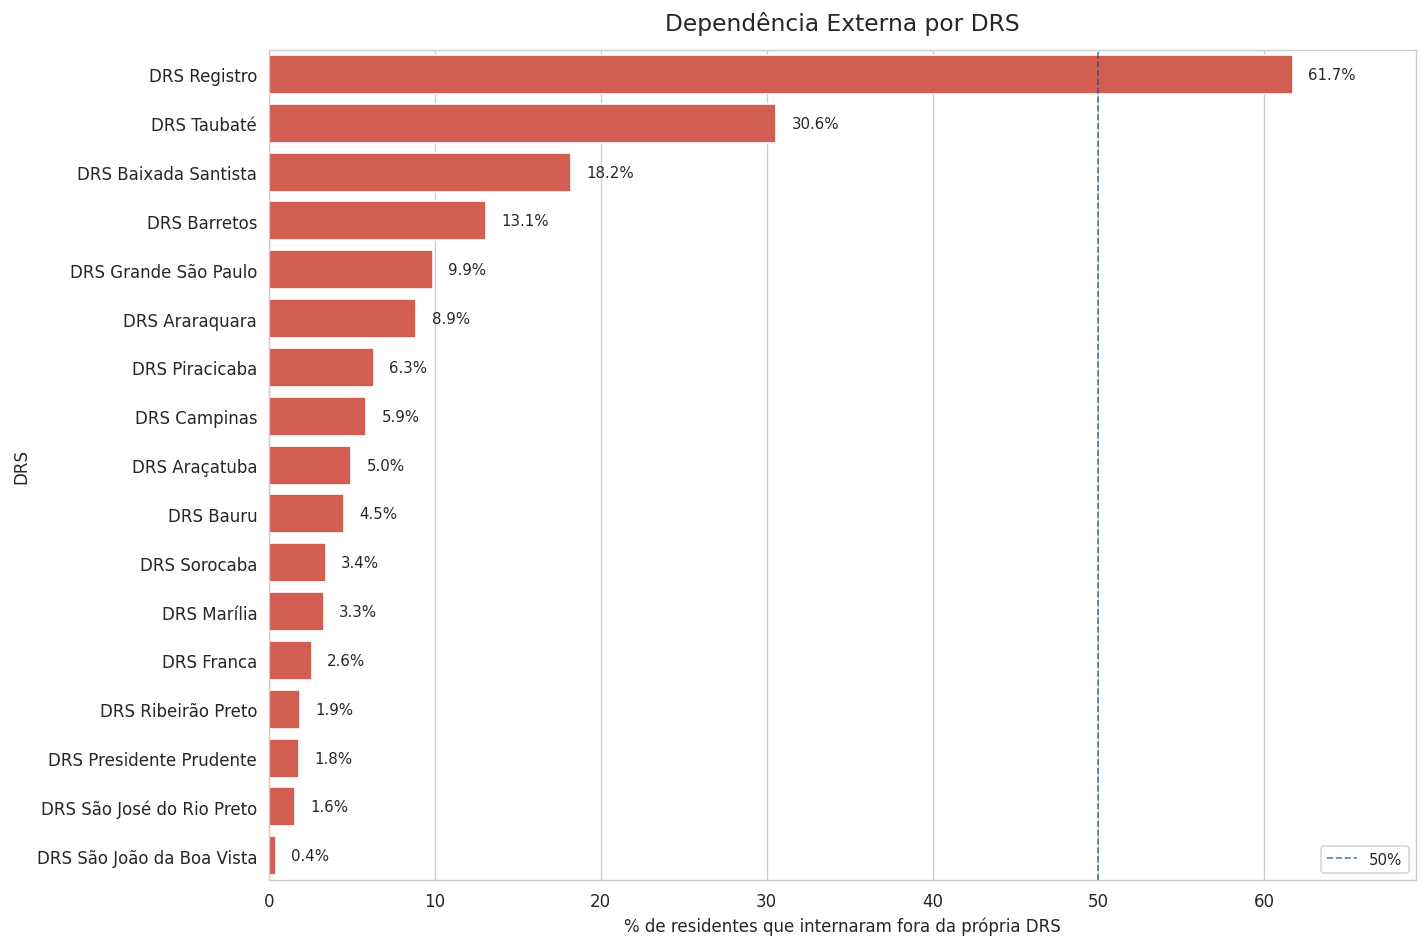

In [ ]:
# =====================================================
# DEPENDÊNCIA EXTERNA POR DRS
# =====================================================

# total internações de residentes da DRS
total_residentes = (
    df.groupby('drs_res')
    .size()
    .reset_index(name='total_internacoes')
)

# enviados para fora
enviados = (
    df[df['fluxo_drs'] == 'fora_drs']
    .groupby('drs_res')
    .size()
    .reset_index(name='internacoes_fora_drs')
)

dependencia_drs = total_residentes.merge(
    enviados,
    on='drs_res',
    how='left'
)

dependencia_drs['internacoes_fora_drs'] = dependencia_drs['internacoes_fora_drs'].fillna(0)

dependencia_drs['dependencia_%'] = (
    dependencia_drs['internacoes_fora_drs'] /
    dependencia_drs['total_internacoes']
* 100).round(2)

dependencia_drs = dependencia_drs.sort_values(
    'dependencia_%',
    ascending=False
)

display(
    dependencia_drs[['drs_res', 'total_internacoes', 'internacoes_fora_drs', 'dependencia_%']]
    .head(15)
)

# -----------------------------------------------------
# GRÁFICO
# -----------------------------------------------------

plt.figure(figsize=(12, 8))

sns.barplot(
    data=dependencia_drs,
    x='dependencia_%',
    y='drs_res',
    order=dependencia_drs['drs_res'],
    color=COLOR_WARN
)

plt.title('Dependência Externa por DRS', fontsize=14, pad=12)
plt.xlabel('% de residentes que internaram fora da própria DRS')
plt.ylabel('DRS')

# linha de referência em 50%
plt.axvline(x=50, color=COLOR1, linestyle='--', linewidth=1, alpha=0.7,
            label='50%')
plt.legend(fontsize=9)

offset = dependencia_drs['dependencia_%'].max() * 0.015

for i, (_, row) in enumerate(dependencia_drs.iterrows()):
    plt.text(
        row['dependencia_%'] + offset,
        i,
        f"{row['dependencia_%']:.1f}%",
        va='center',
        fontsize=9
    )

plt.xlim(right=dependencia_drs['dependencia_%'].max() * 1.12)
plt.tight_layout()
plt.show()

✓ Consistência verificada


,drs_res,total_internacoes,internacoes_na_propria_drs,autossuficiencia_%
15,DRS São João da Boa Vista,106171,105731,99.59
14,DRS São José do Rio Preto,61832,60848,98.41
10,DRS Presidente Prudente,49255,48358,98.18
12,DRS Ribeirão Preto,50723,49763,98.11
6,DRS Franca,32750,31902,97.41
8,DRS Marília,89222,86279,96.70
13,DRS Sorocaba,55155,53271,96.58
4,DRS Bauru,56060,53509,95.45
1,DRS Araçatuba,16427,15609,95.02
5,DRS Campinas,99363,93543,94.14


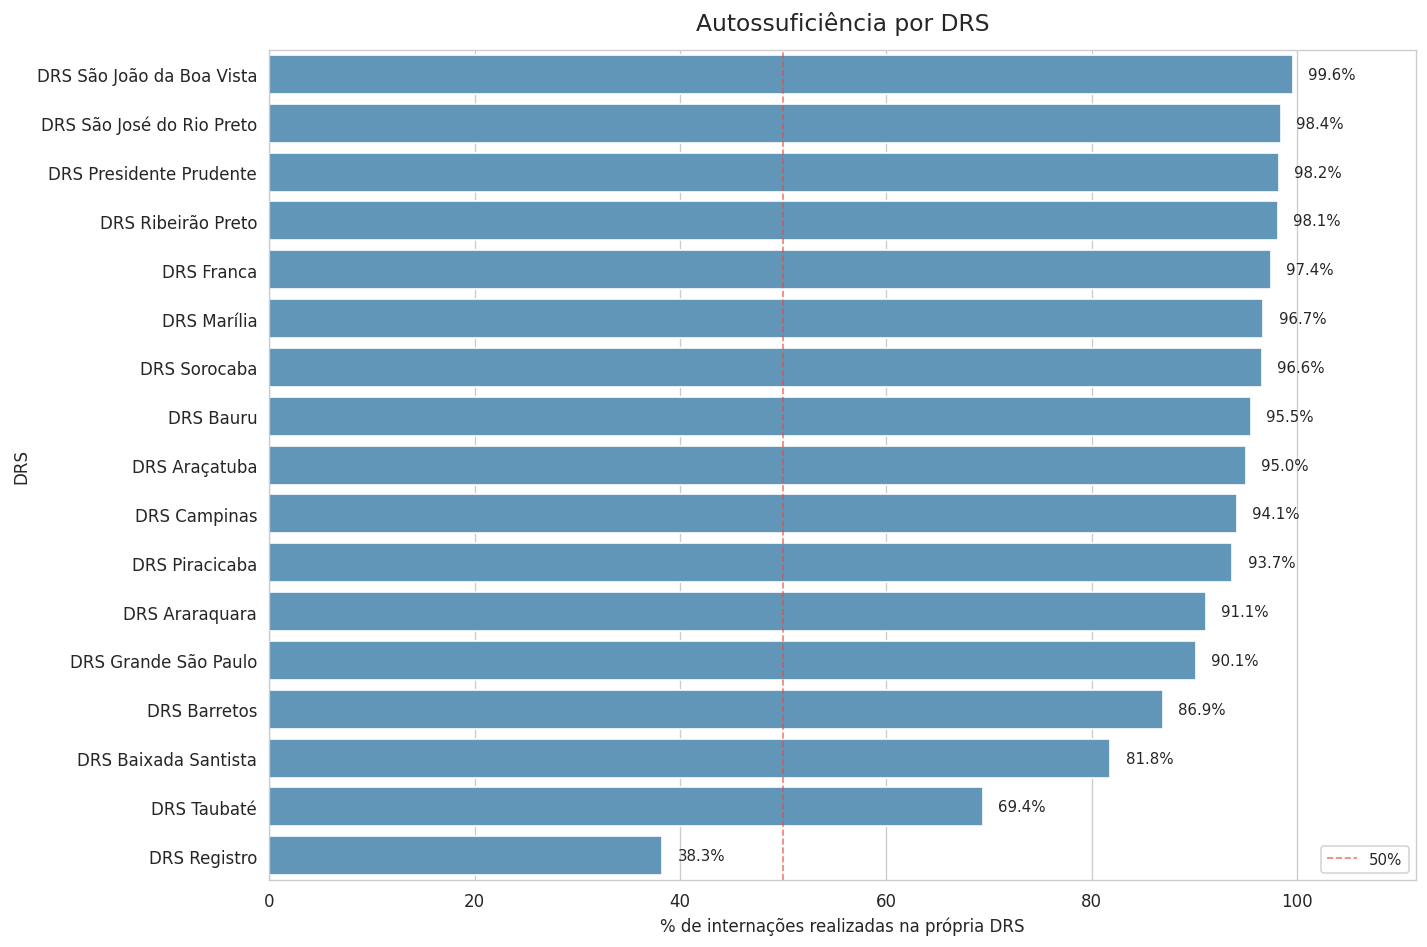

In [ ]:
# =====================================================
# AUTOSSUFICIÊNCIA POR DRS
# =====================================================

mesma_drs = (
    df[df['fluxo_drs'] == 'mesma_drs']
    .groupby('drs_res')
    .size()
    .reset_index(name='internacoes_na_propria_drs')
)

autossuf = total_residentes.merge(
    mesma_drs,
    on='drs_res',
    how='left'
)

autossuf['internacoes_na_propria_drs'] = autossuf['internacoes_na_propria_drs'].fillna(0)

autossuf['autossuficiencia_%'] = (
    autossuf['internacoes_na_propria_drs'] /
    autossuf['total_internacoes']
* 100).round(2)

autossuf = autossuf.sort_values('autossuficiencia_%', ascending=False)

# -----------------------------------------------------
# CHECAGEM DE CONSISTÊNCIA
# -----------------------------------------------------

check = autossuf.merge(
    dependencia_drs[['drs_res', 'dependencia_%']],
    on='drs_res',
    how='left'
)
check['soma'] = check['autossuficiencia_%'] + check['dependencia_%']
assert check['soma'].between(99.9, 100.1).all(), "Inconsistência entre autossuficiência e dependência!"
print("✓ Consistência verificada")

# -----------------------------------------------------
# RESULTADO TABELA
# -----------------------------------------------------

display(
    autossuf[['drs_res', 'total_internacoes', 'internacoes_na_propria_drs', 'autossuficiencia_%']]
    .head(15)
)

# -----------------------------------------------------
# GRÁFICO
# -----------------------------------------------------

plt.figure(figsize=(12, 8))

sns.barplot(
    data=autossuf,
    x='autossuficiencia_%',
    y='drs_res',
    order=autossuf['drs_res'],
    color=COLOR3
)

plt.title('Autossuficiência por DRS', fontsize=14, pad=12)
plt.xlabel('% de internações realizadas na própria DRS')
plt.ylabel('DRS')

# linha de referência em 50%
plt.axvline(x=50, color=COLOR_WARN, linestyle='--', linewidth=1, alpha=0.7,
            label='50%')
plt.legend(fontsize=9)

offset = autossuf['autossuficiencia_%'].max() * 0.015

for i, (_, row) in enumerate(autossuf.iterrows()):
    plt.text(
        row['autossuficiencia_%'] + offset,
        i,
        f"{row['autossuficiencia_%']:.1f}%",
        va='center',
        fontsize=9
    )

plt.xlim(right=autossuf['autossuficiencia_%'].max() * 1.12)
plt.tight_layout()
plt.show()

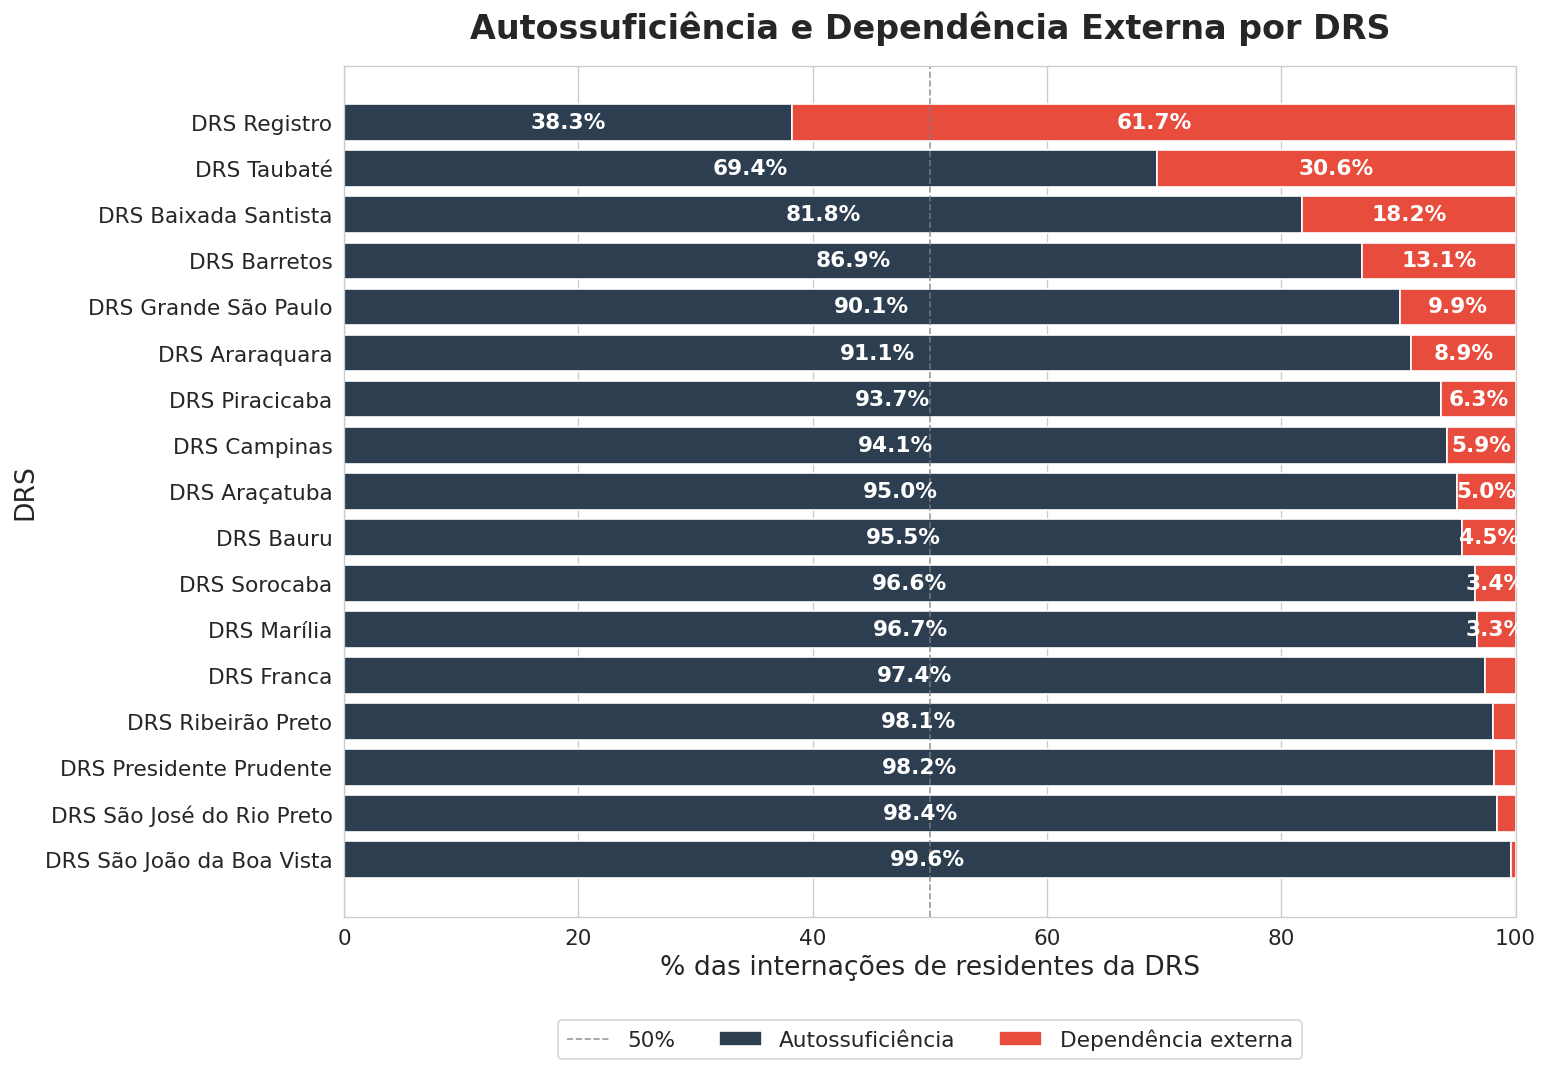

In [ ]:
# =====================================================
# AUTOSSUFICIÊNCIA + DEPENDÊNCIA EXTERNA POR DRS
# =====================================================

import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------------------------------
# JUNTAR AS DUAS MÉTRICAS NA MESMA BASE
# -----------------------------------------------------

grafico_fluxo_drs = autossuf[
    ['drs_res', 'total_internacoes', 'autossuficiencia_%']
].merge(
    dependencia_drs[['drs_res', 'dependencia_%']],
    on='drs_res',
    how='left'
)

# -----------------------------------------------------
# ORDENAR PELA MAIOR DEPENDÊNCIA EXTERNA
# -----------------------------------------------------

grafico_fluxo_drs = grafico_fluxo_drs.sort_values(
    'dependencia_%',
    ascending=True
)

# -----------------------------------------------------
# CRIAR GRÁFICO DE BARRAS EMPILHADAS 100%
# -----------------------------------------------------

fig, ax = plt.subplots(figsize=(13, 9))

# Parte azul: autossuficiência
ax.barh(
    grafico_fluxo_drs['drs_res'],
    grafico_fluxo_drs['autossuficiencia_%'],
    label='Autossuficiência',
    color='#2C3E50'
)

# Parte vermelha: dependência externa
ax.barh(
    grafico_fluxo_drs['drs_res'],
    grafico_fluxo_drs['dependencia_%'],
    left=grafico_fluxo_drs['autossuficiencia_%'],
    label='Dependência externa',
    color='#E74C3C'
)

# Linha de referência em 50%
ax.axvline(
    x=50,
    linestyle='--',
    linewidth=1,
    color='gray',
    alpha=0.8,
    label='50%'
)

# -----------------------------------------------------
# INSERIR OS PERCENTUAIS NAS BARRAS
# -----------------------------------------------------

for i, (_, row) in enumerate(grafico_fluxo_drs.iterrows()):

    # Texto da autossuficiência
    if row['autossuficiencia_%'] >= 8:
        ax.text(
            row['autossuficiencia_%'] / 2,
            i,
            f"{row['autossuficiencia_%']:.1f}%",
            va='center',
            ha='center',
            fontsize=13,
            color='white',
            fontweight='bold'
        )

    # Texto da dependência externa
    if row['dependencia_%'] >= 3:
        ax.text(
            row['autossuficiencia_%'] + row['dependencia_%'] / 2,
            i,
            f"{row['dependencia_%']:.1f}%",
            va='center',
            ha='center',
            fontsize=13,
            color='white',
            fontweight='bold'
        )

# -----------------------------------------------------
# AJUSTES VISUAIS
# -----------------------------------------------------

ax.set_title(
    'Autossuficiência e Dependência Externa por DRS',
    fontsize=20,
    fontweight='bold',
    pad=16
)

ax.set_xlabel(
    '% das internações de residentes da DRS',
    fontsize=16
)

ax.set_ylabel(
    'DRS',
    fontsize=16
)

ax.set_xlim(0, 100)

# aumentar números dos eixos
ax.tick_params(
    axis='x',
    labelsize=13
)

ax.tick_params(
    axis='y',
    labelsize=13
)

# legenda maior e fora
ax.legend(
    loc='lower center',
    bbox_to_anchor=(0.5, -0.18),
    ncol=3,
    fontsize=13,
    title_fontsize=14
)

plt.tight_layout()
plt.show()

In [ ]:
# =====================================================
# FLUXO PRÉ / PANDEMIA / PÓS
# =====================================================

fluxo_periodo = (
    pd.crosstab(
        df['periodo_pandemia'],
        df['fluxo_drs'],
        normalize='index'
    ) * 100
).round(2)

print(fluxo_periodo)


fluxo_drs         fora_drs  mesma_drs
periodo_pandemia                     
pandemia              5.54      94.46
pos-pandemia          6.81      93.19
pre-pandemia          8.04      91.96


In [ ]:
# =====================================================
# MATRIZ ORIGEM x DESTINO ENTRE DRS
# =====================================================

matriz_fluxo = pd.crosstab(
    df['drs_res'],
    df['drs_mov']
)

print(matriz_fluxo)

drs_mov                    DRS Araraquara  DRS Araçatuba  \
drs_res                                                    
DRS Araraquara                      14281              5   
DRS Araçatuba                           3          15609   
DRS Baixada Santista                    2              0   
DRS Barretos                            2              5   
DRS Bauru                              14             15   
DRS Campinas                           18              1   
DRS Franca                              9              1   
DRS Grande São Paulo                   23              5   
DRS Marília                             5             14   
DRS Piracicaba                         19              3   
DRS Presidente Prudente                 3              4   
DRS Registro                            0              0   
DRS Ribeirão Preto                     25              0   
DRS Sorocaba                            3              2   
DRS São José do Rio Preto              2

TOP 20 PARES DRS ORIGEM → DESTINO


,drs_res,drs_mov,n_internacoes,pct_total
107,DRS Grande São Paulo,DRS São João da Boa Vista,22813,30.42
213,DRS Taubaté,DRS São João da Boa Vista,12506,16.68
105,DRS Grande São Paulo,DRS Sorocaba,6881,9.18
78,DRS Campinas,DRS São João da Boa Vista,3681,4.91
36,DRS Baixada Santista,DRS São João da Boa Vista,2698,3.60
113,DRS Marília,DRS Bauru,2167,2.89
104,DRS Grande São Paulo,DRS Ribeirão Preto,2029,2.71
152,DRS Registro,DRS Sorocaba,1432,1.91
57,DRS Bauru,DRS Marília,1363,1.82
70,DRS Campinas,DRS Grande São Paulo,1069,1.43


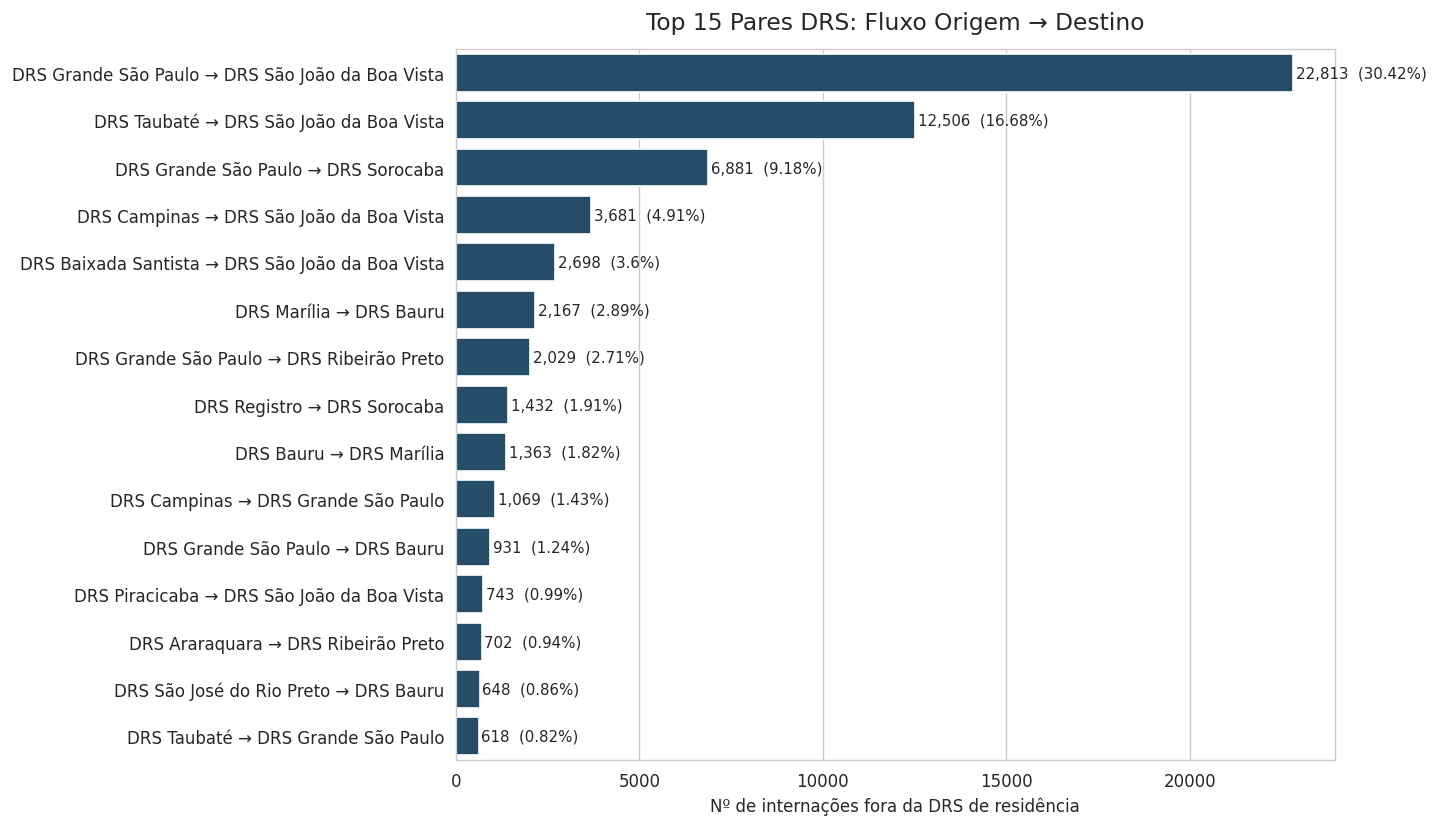

In [ ]:
# =====================================================
# PRINCIPAIS PARES DRS ORIGEM → DESTINO
# =====================================================

pares_drs = (
    df[df['fluxo_drs'] == 'fora_drs']
    .groupby(['drs_res', 'drs_mov'])
    .size()
    .reset_index(name='n_internacoes')
    .sort_values('n_internacoes', ascending=False)
)

# Excluir pares onde origem == destino
pares_drs = pares_drs[pares_drs['drs_res'] != pares_drs['drs_mov']]

# % do total de fluxos inter-DRS
total_fora = pares_drs['n_internacoes'].sum()
pares_drs['pct_total'] = (pares_drs['n_internacoes'] / total_fora * 100).round(2)

print("TOP 20 PARES DRS ORIGEM → DESTINO")
display(pares_drs.head(20))

# ---------------------------------------------------
# GRÁFICO - Top 15 pares
# ---------------------------------------------------

top15_pares = pares_drs.head(15).copy()
top15_pares['par'] = top15_pares['drs_res'] + ' → ' + top15_pares['drs_mov']

fig, ax = plt.subplots(figsize=(12, 7))

bars = sns.barplot(
    data=top15_pares,
    x='n_internacoes',
    y='par',
    order=top15_pares['par'],
    color=COLOR1,
    ax=ax
)

ax.set_title('Top 15 Pares DRS: Fluxo Origem → Destino', fontsize=14, pad=12)
ax.set_xlabel('Nº de internações fora da DRS de residência')
ax.set_ylabel('')

for i, (v, pct) in enumerate(zip(top15_pares['n_internacoes'], top15_pares['pct_total'])):
    ax.text(v + total_fora * 0.001, i, f'{v:,.0f}  ({pct}%)', va='center', fontsize=9)

plt.tight_layout()
plt.show()

Municípios com DRS mapeada: 645 / 645
Municípios com autossuficiência: 645


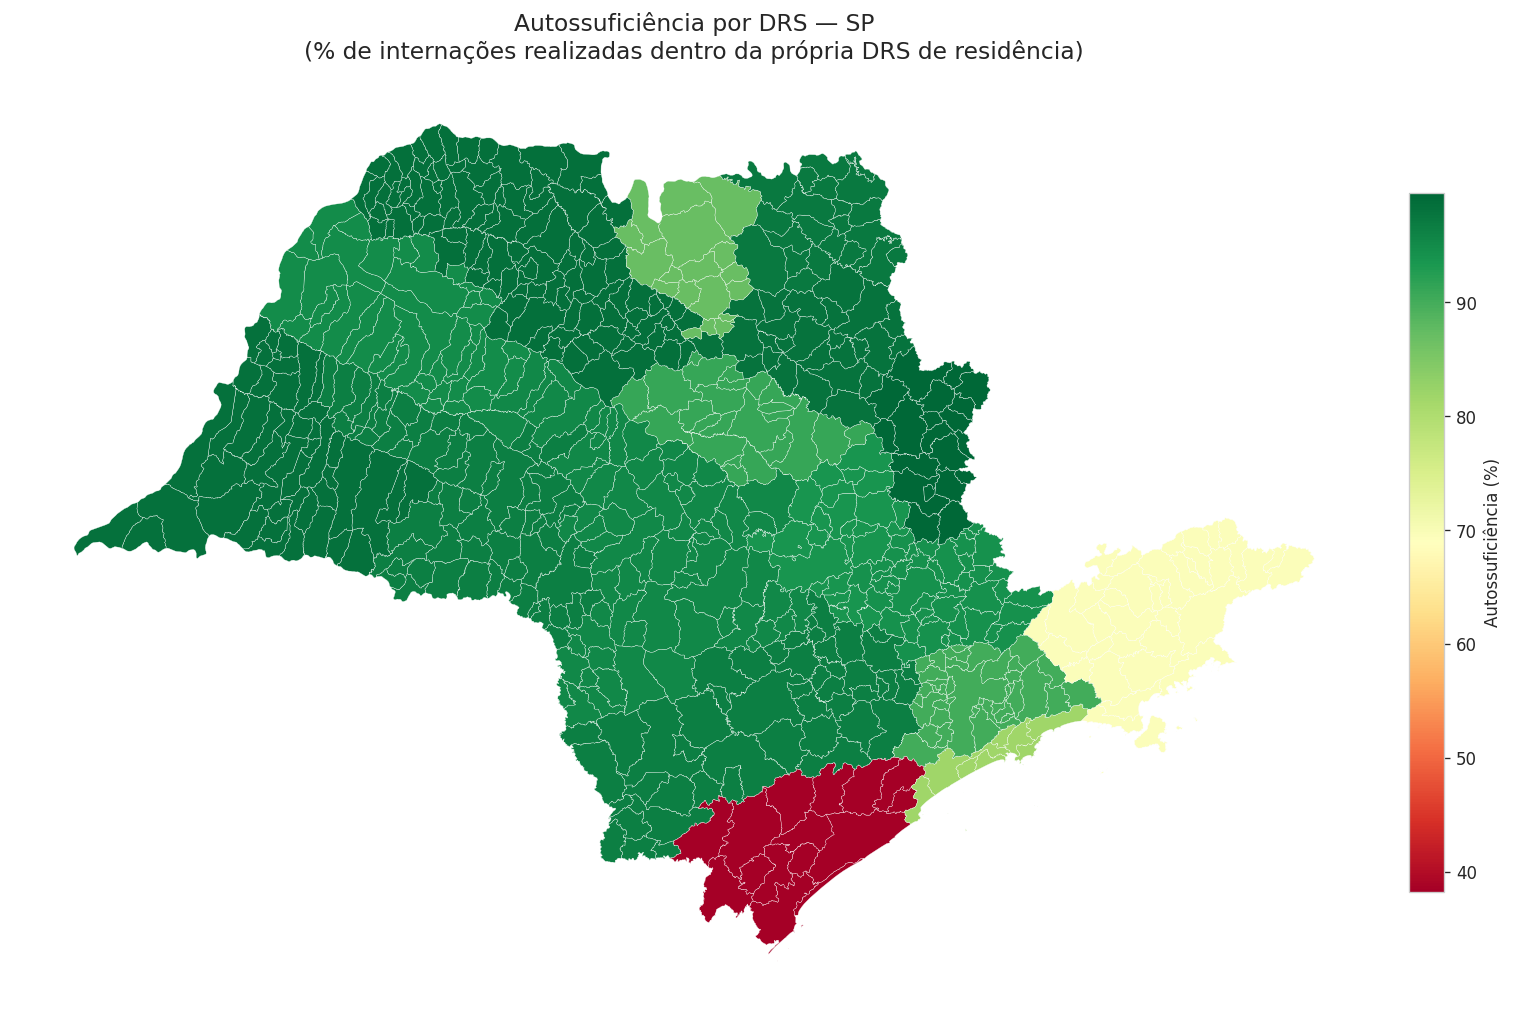

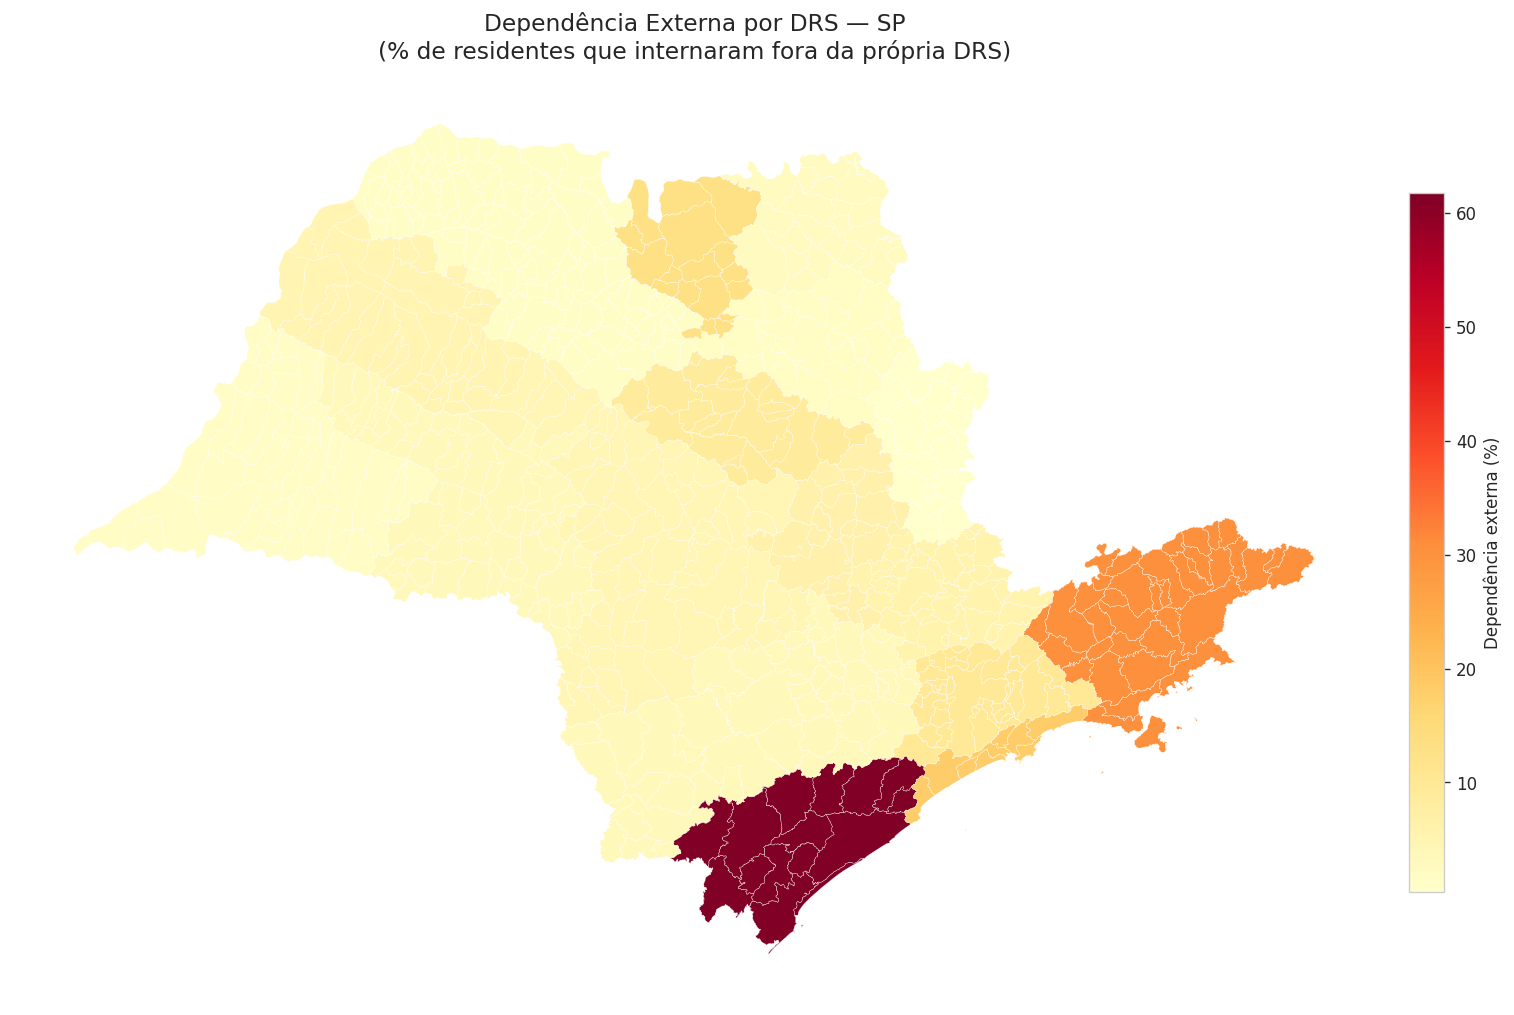

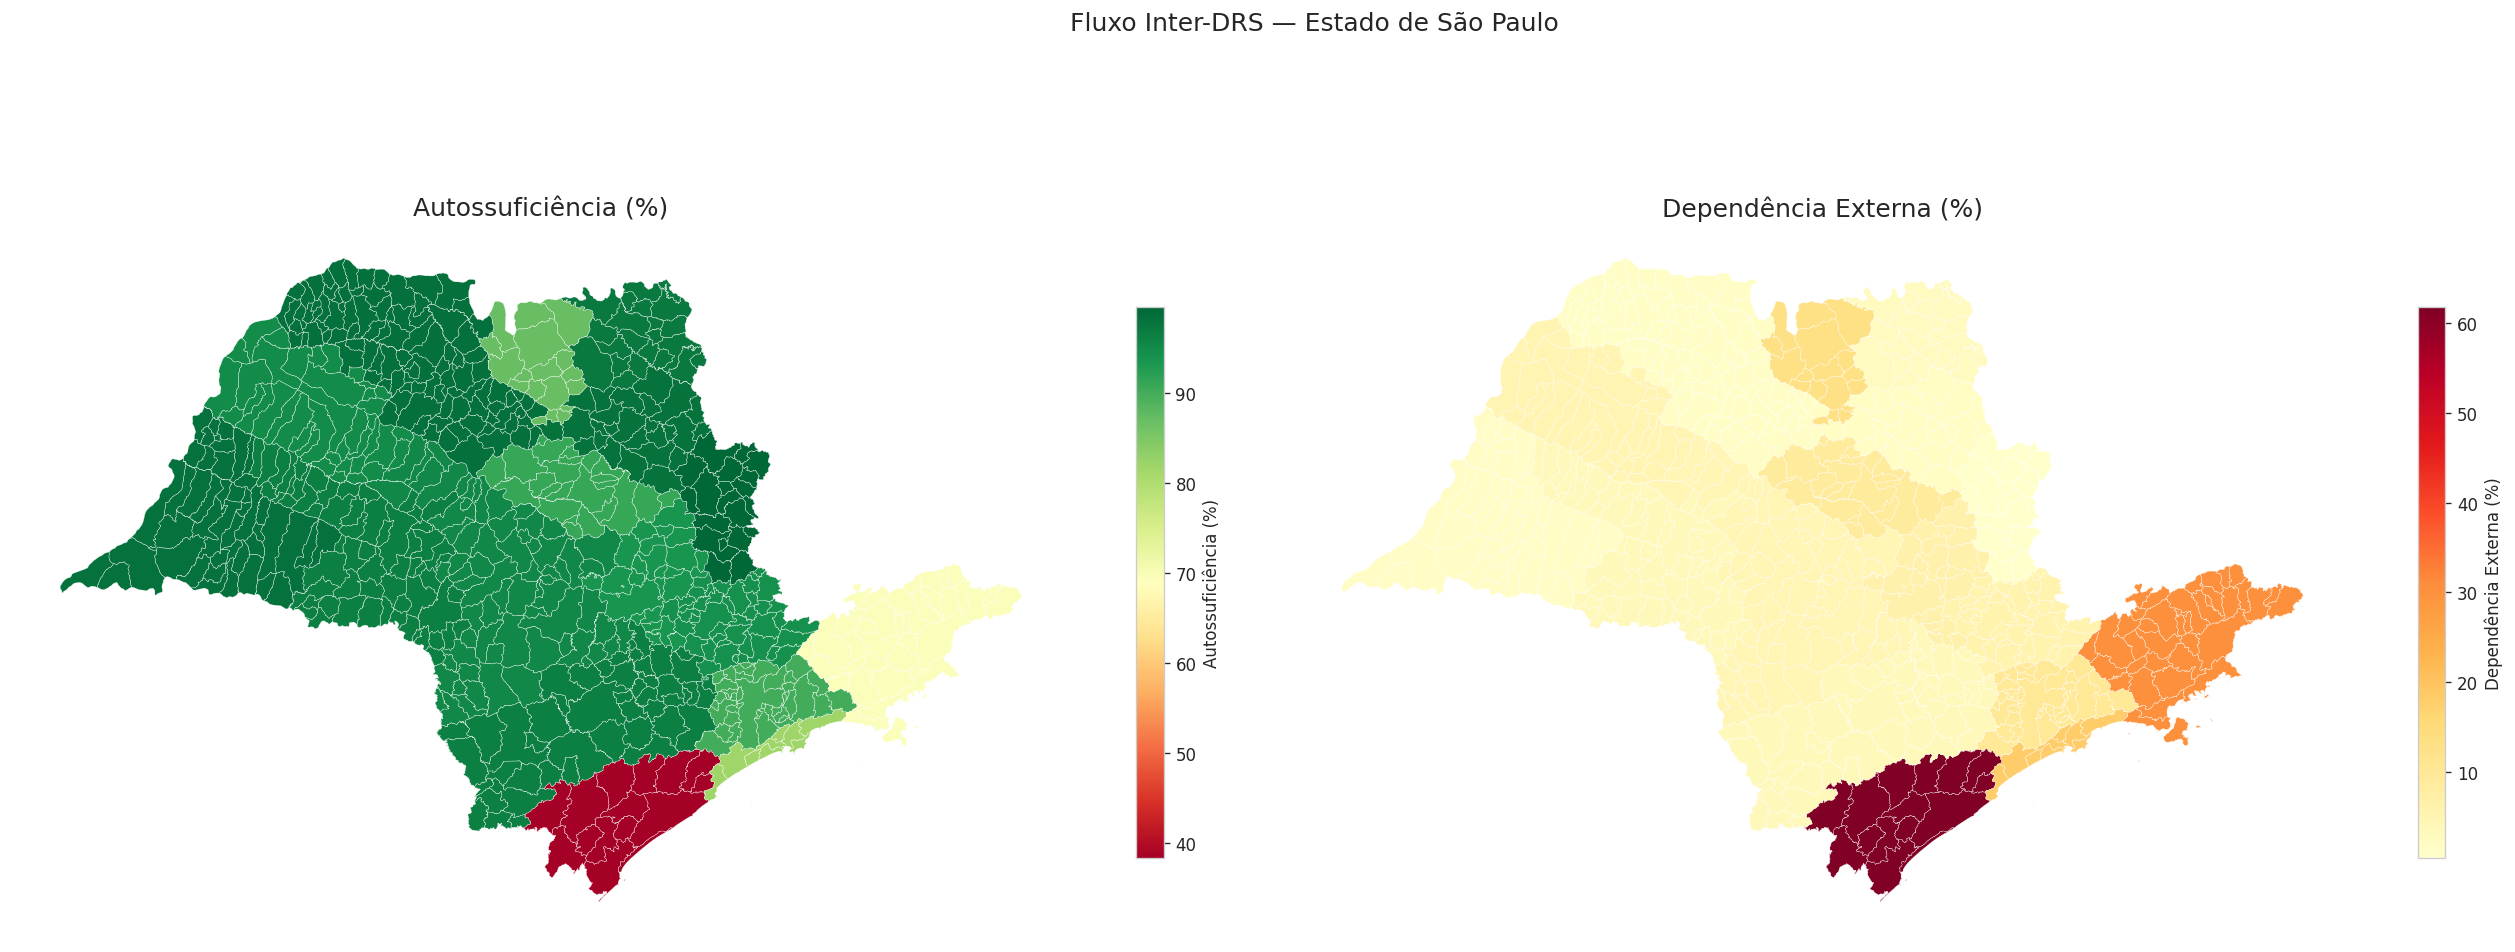

In [ ]:
# =====================================================
# MAPA COROPLÉTICO - AUTOSSUFICIÊNCIA POR DRS
# =====================================================
# Usa o df_drs (municipio → DRS) e municipios_sp (geometria)
# e o df 'autossuf' calculado na seção anterior

# ---------------------------------------------------
# JUNTAR GEOMETRIA COM INDICADORES
# ---------------------------------------------------

# Trazer DRS para cada município
mapa_drs = municipios_sp.merge(
    df_drs[['cod_municipio', 'drs']],
    left_on='cod6',
    right_on='cod_municipio',
    how='left'
)

# Juntar autossuficiência
mapa_drs = mapa_drs.merge(
    autossuf[['drs_res', 'autossuficiencia_%']].rename(columns={'drs_res': 'drs'}),
    on='drs',
    how='left'
)

# Juntar dependência
mapa_drs = mapa_drs.merge(
    dependencia_drs[['drs_res', 'dependencia_%']].rename(columns={'drs_res': 'drs'}),
    on='drs',
    how='left'
)

print(f"Municípios com DRS mapeada: {mapa_drs['drs'].notna().sum()} / {len(mapa_drs)}")
print(f"Municípios com autossuficiência: {mapa_drs['autossuficiencia_%'].notna().sum()}")

# ---------------------------------------------------
# MAPA: AUTOSSUFICIÊNCIA POR DRS
# ---------------------------------------------------

fig, ax = plt.subplots(1, 1, figsize=(14, 10))

mapa_drs.plot(
    column='autossuficiencia_%',
    ax=ax,
    legend=True,
    cmap='RdYlGn',          # vermelho = baixa, verde = alta autossuficiência
    missing_kwds={
        'color': '#cccccc',
        'label': 'Sem dados'
    },
    legend_kwds={
        'label': 'Autossuficiência (%)',
        'orientation': 'vertical',
        'shrink': 0.6,
        'pad': 0.02
    },
    edgecolor='white',
    linewidth=0.2
)

ax.set_title(
    'Autossuficiência por DRS — SP\n'
    '(% de internações realizadas dentro da própria DRS de residência)',
    fontsize=14, pad=14
)
ax.axis('off')

plt.tight_layout()
plt.show()

# ---------------------------------------------------
# MAPA: DEPENDÊNCIA EXTERNA POR DRS
# ---------------------------------------------------

fig, ax = plt.subplots(1, 1, figsize=(14, 10))

mapa_drs.plot(
    column='dependencia_%',
    ax=ax,
    legend=True,
    cmap='YlOrRd',          # amarelo = baixa, vermelho = alta dependência
    missing_kwds={
        'color': '#cccccc',
        'label': 'Sem dados'
    },
    legend_kwds={
        'label': 'Dependência externa (%)',
        'orientation': 'vertical',
        'shrink': 0.6,
        'pad': 0.02
    },
    edgecolor='white',
    linewidth=0.2
)

ax.set_title(
    'Dependência Externa por DRS — SP\n'
    '(% de residentes que internaram fora da própria DRS)',
    fontsize=14, pad=14
)
ax.axis('off')

plt.tight_layout()
plt.show()

# ---------------------------------------------------
# PAINEL LADO A LADO
# ---------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(22, 9))

for ax, col, cmap, titulo in zip(
    axes,
    ['autossuficiencia_%', 'dependencia_%'],
    ['RdYlGn', 'YlOrRd'],
    ['Autossuficiência (%)', 'Dependência Externa (%)']
):
    mapa_drs.plot(
        column=col, ax=ax, legend=True, cmap=cmap,
        missing_kwds={'color': '#cccccc', 'label': 'Sem dados'},
        legend_kwds={'label': titulo, 'orientation': 'vertical', 'shrink': 0.55},
        edgecolor='white', linewidth=0.2
    )
    ax.set_title(titulo, fontsize=15)
    ax.axis('off')

fig.suptitle('Fluxo Inter-DRS — Estado de São Paulo', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()